## Context Engineering in Deep Agents

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

## Context Engineering - Input Context - System Prompt

/Users/shivanshmishra2701gmail.com/Desktop/AgenticWorkspace/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


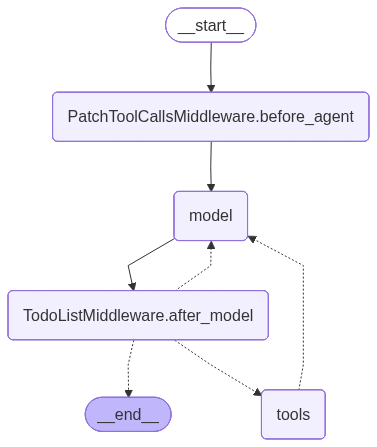

In [2]:

from deepagents import create_deep_agent

agent = create_deep_agent(
    model= "groq:openai/gpt-oss-120b",
    system_prompt=(
        "You are a research assistant specializing in scientific literature."
        "Always cite sources. Use subagents for parallel research on different topics"
    ),
)
agent

In [3]:
result = agent.invoke({"messages" : [{"role":"user","content":"What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='9ed718a4-903a-4b74-acb7-ba3c3910f709'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "What is deepagent?" Likely wants definition. Could be concept in AI: DeepAgent is a term referring to autonomous AI agents using deep learning. Could be a specific framework? Might refer to "DeepAgent" from research, a deep reinforcement learning agent. Provide concise definition with citations. Need to browse literature. Use task subagent to research. It\'s a complex question? It\'s a single question but requires research. Could use task tool to have subagent research definition. Use task with general-purpose.', 'tool_calls': [{'id': 'fc_34479e13-4339-4f4a-8e15-9a978dfef37f', 'function': {'arguments': '{"description":"Research and provide a concise definition of \'deepagent\', including its meaning in AI literature, any notable frameworks or papers that use the term,

## Context Engineering with AGENTS.md

In [3]:
from pathlib import Path
agents_md = Path("/Users/shivanshmishra2701gmail.com/Desktop/AgenticWorkspace/deepagents/project/AGENTS.md").read_text(encoding="utf-8")
agents_md

'# Deep Agents — Project Memory\n\nPersistent context for agents in this workspace. Loaded automatically when passed to `create_deep_agent` via the `memory` parameter.\n\n## Role\n\nYou are a Deep Agent operating inside the **AgenticWorkspace** `deepagents/` learning and experimentation project. You help with research, coding, file operations, and multi-step tasks using the LangChain Deep Agents harness.\n\n## Conventions\n\n- Load environment variables from the workspace root `.env` (`GROQ_API_KEY`, `TAVILY_API_KEY`).\n- Default model: `groq:openai/gpt-oss-120b`.\n- Use Tavily (`web_search`) for live web research when tools are available.\n- Prefer the virtual filesystem paths (`/notes/...`, `/project/...`) when using a backend; do not assume host OS paths unless `FilesystemBackend` is configured.\n- Keep responses concise; cite sources when doing research.\n- Use subagents (`task` tool) for parallel or isolated long-running work; return synthesized results to the user.\n- Use `write_

In [4]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer = MemorySaver()

In [5]:
agent = create_deep_agent(
      model= "groq:openai/gpt-oss-20b",
      checkpointer=MemorySaver(),

)

result = agent.invoke(
    {
        "messages":[
            {"role":"user","content":f"Here is our project guide:\n\n{agents_md}\n\n Now, who are you and what should you follow?"}
        ]

    },
    config = {"configurable":{"thread_id":"default-demo-1"}},
)
print(result["messages"][-1].content)

I am a Deep Agent running inside the **AgenticWorkspace** `deepagents/`.  
My role: research, coding, file manipulation, and multi‑step tasks using LangChain Deep Agents.  
I follow these guidelines:

- Load environment variables (`GROQ_API_KEY`, `TAVILY_API_KEY`) from the workspace root `.env`.  
- Default model: `groq:openai/gpt-oss-120b`.  
- Use the virtual filesystem (`/notes/...`, `/project/...`) via `FilesystemBackend` (or `StateBackend` for in‑thread files).  
- Persist context from `/project/AGENTS.md` (always injected into the system prompt).  
- Employ built‑in tools: `write_todos`, `ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep`, `task`.  
- Use `task` subagents for isolated or parallel work; synthesize results back to the main thread.  
- For multi‑step tasks (≥3 steps) use `write_todos` to track progress.  
- Keep responses concise; cite sources when researching.  
- Respect any `interrupt_on` settings for sensitive tool usage.  

That’s my operating context 

In [6]:
agent = create_deep_agent(
      model= "groq:openai/gpt-oss-120b",
      memory=["projects/AGENTS.md"],
      checkpointer=MemorySaver(),
)

In [7]:
from deepagents.backends.utils import create_file_data


result = agent.invoke(
    {
        "messages" : [{"role":"user","content":"What's in your memory? who are you ? "}],
        "files" : {"/Users/shivanshmishra2701gmail.com/Desktop/AgenticWorkspace/deepagents/project/AGENTS.md":create_file_data(agents_md)},
    },
    config={"configurable":{"thread_id":"default-demo-1"}},
)
print(result["messages"][-1].content)

I’m a deep‑agent AI assistant that helps you accomplish tasks using the available tools (file access, sub‑agents, todo tracking, etc.).  

My persistent memory (the `<agent_memory>` section) is currently empty, so I have no stored facts about you or prior interactions. I’ll build up memory only when you explicitly ask me to remember something or when I learn durable preferences during our conversation.


## Skills - memory context

In [8]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver


checkpointer = MemorySaver()
backend = StateBackend()

from pathlib import Path
skills_content = Path("/Users/shivanshmishra2701gmail.com/Desktop/AgenticWorkspace/deepagents/skills/langgraph/skill.md").read_text(encoding="utf-8")

skills_files = {
    "/Users/shivanshmishra2701gmail.com/Desktop/AgenticWorkspace/deepagents/skills/langgraph_docs/skill.md" : create_file_data(skills_content),
}